# 🎬 Analysis of post-pandemic cinema
---

### Imports:

In [28]:
import pandas as pd
import sqlite3 as sql3
import seaborn as sea
import matplotlib.pyplot as plt


conn = sql3.connect("database/cinema.db")

def readquery(file):
    with open (f"database/{file}.sql", "r") as openfile:
        return openfile.read()

def formatnumber(num):
    return f"{num:,.0f}".replace(",",".")

### Are movies still profitable? 

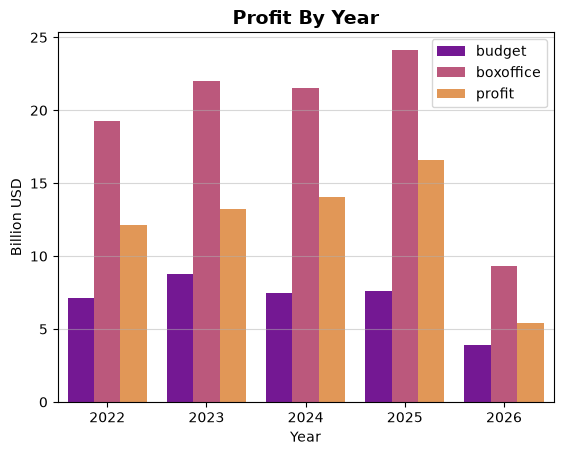

In [29]:
query = readquery("question1")

df = pd.read_sql_query(query, con=conn)

df = df.melt(
    id_vars="releaseYear",
    var_name="financial",
    value_name="amount"
)

df["amount"] = df["amount"]/1000000000

sea.barplot(
    data=df,
    x="releaseYear",
    y="amount",
    hue="financial",
    palette="plasma",
    hue_order=["budget","boxoffice","profit"]
)

plt.title("Profit By Year", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Billion USD")
plt.legend(title="")
plt.grid(axis="y", linestyle="-", alpha=0.5)

plt.show()

The graph suggests that the answer is yes. The stabilization of production budgets alongside the steady increase in profits indicates that films are generating progressively higher revenues while production costs remain relatively stable. This finding suggests that audience growth is not necessarily driven by increasing production budgets, but rather by changes in audience behavior and/or in the way films are marketed and distributed.

### Profitability by Genre

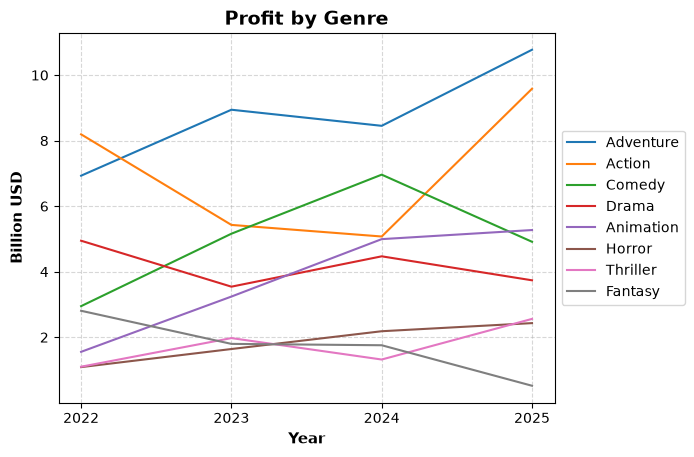

In [30]:
query = readquery("question2")

df = pd.read_sql(query, conn)

df["profit"] = df["profit"]/1000000000
df["releaseYear"] = df["releaseYear"].astype(str)


sea.lineplot(data=df, x="releaseYear", y="profit", hue="genres")

plt.title("Profit by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Billion USD", fontsize=11, fontweight="bold")
plt.legend(title="")
plt.grid(linestyle="--", alpha=0.5)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

plt.show()

Among the most profitable genres are Action and Adventure, which are also the most common genres in the dataset. This is partly because they are considered relatively "safe" investments within the film industry, appealing to broader audiences. However, these genres also require significantly larger production budgets. For this reason, we will analyze ROI (Return on Investment), which provides a clearer measure of which genres generate the highest returns relative to their production costs. It is also worth highlighting the steady upward trend that the Horror genre has experienced in recent years.

### Return on Investment

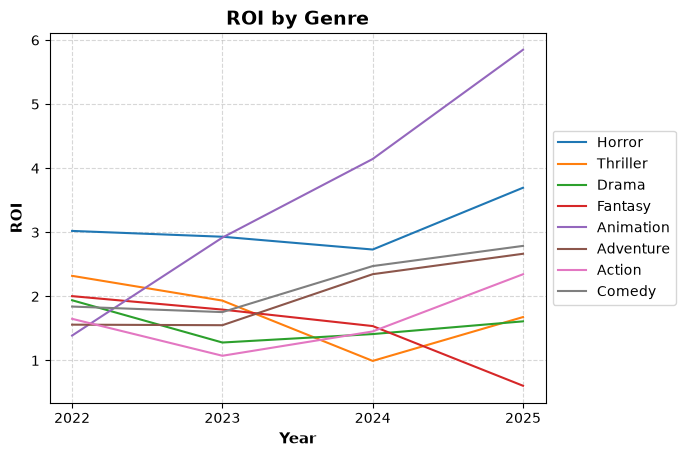

In [31]:
query = readquery("question3")

df = pd.read_sql(query, conn)
df = df.sort_values("releaseYear") 
df["releaseYear"] = df["releaseYear"].astype(str)

sea.lineplot(data=df, x="releaseYear", y="roi", hue="genres")

plt.title("ROI by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Year",fontsize=11, fontweight="bold")
plt.ylabel("ROI", fontsize=11, fontweight="bold")
plt.legend(title="")
plt.grid(linestyle="--", alpha=0.5)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

plt.show()

Although Action and Adventure generate the highest overall profits, they return an average of 2.5 times their production budgets. By comparison, Animation and Horror achieve remarkable returns, reaching 5.8× and 3.7× their production budgets, respectively, in 2025. These results suggest that expensive genres are not necessarily more efficient at converting production costs into profit.

### Costs

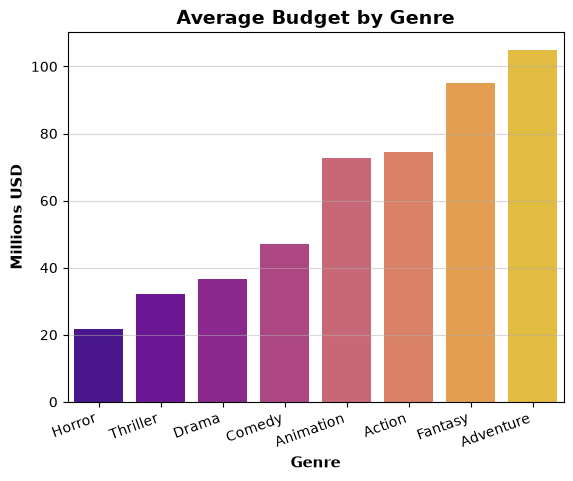

In [32]:
query = readquery("question5")

df = pd.read_sql_query(query, con=conn)
df["budget"] = df["budget"]/1000000

sea.barplot(
    data=df,
    x="genres",
    y="budget",
    palette="plasma",
    hue="genres"
)


plt.title("Average Budget by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Genre",fontsize=11, fontweight="bold")
plt.ylabel("Millions USD", fontsize=11, fontweight="bold")
plt.grid(axis="y",linestyle="-", alpha=0.5)
plt.xticks(rotation=20, ha="right")

plt.show()

Following this line of reasoning, Horror stands out as a particularly strong performer, as it has the lowest average production budget among the most profitable genres. Genres with more grounded narratives typically keep their production budgets below $50 million, whereas genres that rely heavily on visual effects consistently exceed $70 million.

### Audience Reception

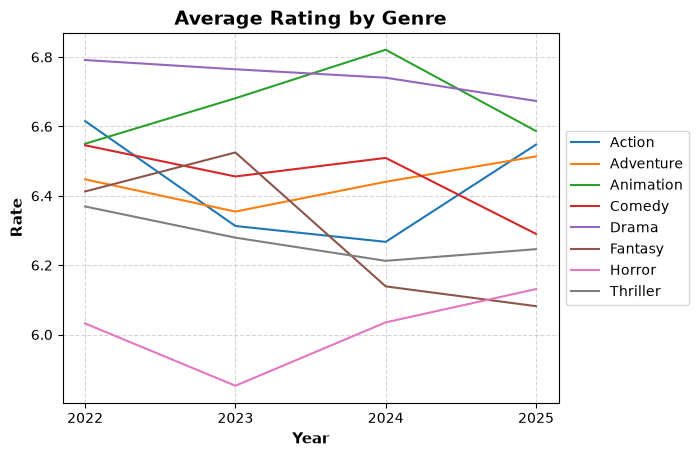

In [33]:
query = readquery("question4")

df = pd.read_sql(query, conn)
df = df.sort_values("releaseYear") 
df["releaseYear"] = df["releaseYear"].astype(str)

sea.lineplot(data=df, x="releaseYear", y="meanRating", hue="genres")

plt.title("Average Rating by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Year",fontsize=11, fontweight="bold")
plt.ylabel("Rate", fontsize=11, fontweight="bold")
plt.legend(title="")
plt.grid(linestyle="--", alpha=0.5)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

plt.show()

Despite its strong financial performance, Horror appears to be a more challenging genre in terms of audience reception, maintaining an average IMDb rating of around 6.0, while the other top-performing genres average approximately 6.6. However, when examining the relationship between ratings and profitability, it becomes clear that most films—regardless of whether they achieve high or modest profits—are concentrated within this rating range. Even critically acclaimed films with significantly higher ratings often generate profits comparable to those of films with average audience scores.

### Most profitable movies of each year 

In [34]:
query = readquery("question6")

df = pd.read_sql(query, conn)
df["Profit"] = df["Profit"].apply(formatnumber)
df.style.hide()

Year,Title,Profit
2022,Avatar: The Way of Water,1.874.484.620
2022,Top Gun: Maverick,1.318.732.821
2022,Minions: The Rise of Gru,855.203.765
2023,Barbie,1.302.138.421
2023,The Super Mario Bros. Movie,1.260.879.735
2023,Oppenheimer,852.000.000
2024,Inside Out 2,1.498.863.816
2024,Deadpool & Wolverine,1.138.073.645
2024,Moana 2,909.242.164
2025,Ne Zha 2,2.179.822.417


At least one of the most profitable films of each year is an animated feature, and after 2024, at least two animated films appear among the top performers. This highlights the importance of the family and children's audience within the film market. China demonstrates its strength through domestic productions, with Ne Zha 2 ranking first in 2025. Disney dominates the podium with its animated features, the Marvel Cinematic Universe, and the Avatar franchise.

### Directors who appear most frequently

In [35]:
query = readquery("question7")

df = pd.read_sql(query, conn)
df["Mean_Rate"] = df["Mean_Rate"].round(2)
df

,Director,Movies,Mean_Rate
0,Guy Ritchie,4,6.72
1,Luca Guadagnino,4,6.45
2,Matt Bettinelli-Olpin,4,6.42
3,Tyler Gillett,4,6.42
4,James Cameron,3,7.43
5,Yorgos Lanthimos,3,7.17
6,Lokesh Kanagaraj,3,7.17
7,Alex Garland,3,6.70
8,Ti West,3,6.57
9,Steven Soderbergh,3,6.00


Matt Bettinelli-Olpin, Tyler Gillett, and Ti West rank among the most frequent directors in the dataset, with all of their entries belonging exclusively to the Horror genre.

### Highest-rated movies

In [36]:
query = readquery("question8")

df = pd.read_sql(query, conn)
df["Votes"] = df["Votes"].apply(formatnumber)
df["Boxoffice"] = df["Boxoffice"].apply(formatnumber)
df

,Title,Year,Votes,Boxoffice
0,Oppenheimer,2023,1.062.339,952.000.000
1,The Batman,2022,935.853,772.775.278
2,Top Gun: Maverick,2022,891.123,1.488.732.821
3,Dune: Part Two,2024,773.003,714.844.358
4,Barbie,2023,696.843,1.447.138.421
5,Everything Everywhere All at Once,2022,655.258,139.200.000
6,Avatar: The Way of Water,2022,639.593,2.334.484.620
7,Deadpool & Wolverine,2024,576.892,1.338.073.645
8,Doctor Strange in the Multiverse of Madness,2022,549.394,955.775.804
9,Bullet Train,2022,541.006,239.268.602


Most of the films in this dataset belong to the Action genre. The chart shows that 2022 dominates the ranking, while no films from 2025 appear, and 2024 is represented by the blockbuster Dune: Part Two and the highly anticipated Deadpool & Wolverine. This highlights the industry's ongoing challenge in creating large-scale cultural events comparable to the "Barbenheimer" phenomenon, which generated more than $2.3 billion. This landscape may change significantly on December 18, with the simultaneous release of Dune: Part Three and Avengers: Doomsday, a pairing that has the potential to break box office records and become another major global cinematic event.

### 🔍 Conclusions:

Based on the points discussed throughout this analysis, it is possible to conclude that major studios are the main players behind "risky" films (high-budget productions). The term "risky" is used in quotation marks because most of these titles already have an established audience and a relatively predictable market appeal. Although cinema is constantly evolving, Action films and Animation continue to prove themselves as profitable and reliable choices for those with the experience and capital required to invest. However, the standout genre in this analysis was Horror, which, despite costing millions of dollars less than the previously mentioned genres and achieving an average ROI of 3.69× in 2025, presents a valuable opportunity for investments in original stories and emerging talent, bringing the creative freshness needed for new cinematic phenomena to emerge.